# Analyse Business E-commerce - RetailRocket

## Objectif
Analyser la performance commerciale du site e-commerce et identifier des leviers d'optimisation.

### Questions business :
1. Quelle est la performance du tunnel de conversion ?
2. Quels sont les comportements des utilisateurs ?
3. Quand les utilisateurs sont-ils les plus actifs ?
4. Quels produits performent le mieux ?
5. Quels axes d'amelioration prioritaires ?

---

In [1]:
# Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Chargement des donnees preparees
events = pd.read_csv('../outputs/data/events_clean.csv')
visitors = pd.read_csv('../outputs/data/visitor_features.csv')
products = pd.read_csv('../outputs/data/product_features.csv')

# Conversion datetime
events['datetime'] = pd.to_datetime(events['datetime'])
events['date'] = pd.to_datetime(events['date'])

print(f"Periode d'analyse : {events['datetime'].min().date()} au {events['datetime'].max().date()}")
print(f"Duree : {(events['datetime'].max() - events['datetime'].min()).days} jours")
print(f"\nDonnees chargees :")
print(f"  - Events : {len(events):,} lignes")
print(f"  - Visiteurs : {len(visitors):,}")
print(f"  - Produits : {len(products):,}")

Periode d'analyse : 2015-05-03 au 2015-09-18
Duree : 137 jours

Donnees chargees :
  - Events : 2,755,641 lignes
  - Visiteurs : 1,407,580
  - Produits : 235,061


---
## 1. KPIs Globaux

Les indicateurs cles de performance pour mesurer la sante du business.

In [2]:
# =============================================================================
# CALCUL DES KPIs PRINCIPAUX
# =============================================================================

# Volumes
total_visitors = events['visitorid'].nunique()
total_sessions = len(events)  # Approximation (1 event = 1 interaction)
total_products = events['itemid'].nunique()

# Comptage par type d'evenement
event_counts = events['event'].value_counts()
n_views = event_counts.get('view', 0)
n_carts = event_counts.get('addtocart', 0)
n_transactions = event_counts.get('transaction', 0)

# Visiteurs uniques par etape
visitors_view = events[events['event'] == 'view']['visitorid'].nunique()
visitors_cart = events[events['event'] == 'addtocart']['visitorid'].nunique()
visitors_purchase = events[events['event'] == 'transaction']['visitorid'].nunique()

# Taux de conversion
view_to_cart_rate = (visitors_cart / visitors_view) * 100
cart_to_purchase_rate = (visitors_purchase / visitors_cart) * 100
overall_conversion_rate = (visitors_purchase / total_visitors) * 100

# Taux d'abandon panier
cart_abandonment_rate = 100 - cart_to_purchase_rate

# Engagement moyen
avg_events_per_visitor = len(events) / total_visitors
avg_products_viewed = visitors['unique_items'].mean()

# Affichage structure
print("=" * 60)
print("TABLEAU DE BORD - KPIs E-COMMERCE")
print("=" * 60)

print("\n[VOLUMES]")
print(f"  Visiteurs uniques      : {total_visitors:>12,}")
print(f"  Interactions totales   : {total_sessions:>12,}")
print(f"  Produits en catalogue  : {total_products:>12,}")

print("\n[ACTIVITE]")
print(f"  Pages vues (view)      : {n_views:>12,}")
print(f"  Ajouts panier          : {n_carts:>12,}")
print(f"  Transactions           : {n_transactions:>12,}")

print("\n[CONVERSION]")
print(f"  Taux View -> Cart      : {view_to_cart_rate:>12.2f}%")
print(f"  Taux Cart -> Achat     : {cart_to_purchase_rate:>12.2f}%")
print(f"  Taux conversion global : {overall_conversion_rate:>12.2f}%")
print(f"  Taux abandon panier    : {cart_abandonment_rate:>12.2f}%")

print("\n[ENGAGEMENT]")
print(f"  Events/visiteur        : {avg_events_per_visitor:>12.1f}")
print(f"  Produits vus/visiteur  : {avg_products_viewed:>12.1f}")

print("\n" + "=" * 60)

TABLEAU DE BORD - KPIs E-COMMERCE

[VOLUMES]
  Visiteurs uniques      :    1,407,580
  Interactions totales   :    2,755,641
  Produits en catalogue  :      235,061

[ACTIVITE]
  Pages vues (view)      :    2,664,218
  Ajouts panier          :       68,966
  Transactions           :       22,457

[CONVERSION]
  Taux View -> Cart      :         2.69%
  Taux Cart -> Achat     :        31.07%
  Taux conversion global :         0.83%
  Taux abandon panier    :        68.93%

[ENGAGEMENT]
  Events/visiteur        :          2.0
  Produits vus/visiteur  :          1.5



### Interpretation Business

**Points cles :**
- **Taux de conversion global < 1%** : Valeur typique pour un e-commerce (moyenne secteur : 1-3%)
- **Abandon panier eleve (~68%)** : Point de friction majeur a optimiser
- **Faible taux view->cart** : Les visiteurs regardent mais n'ajoutent pas au panier

**Diagnostic :**
Le site genere du trafic mais la transformation est faible. Le principal levier est l'optimisation du passage view -> add to cart.

---
## 2. Analyse du Tunnel de Conversion (Funnel)

FUNNEL DE CONVERSION
         Etape  Visiteurs  Pourcentage  Taux_etape     Perte
  1. Visiteurs    1407580       100.00         NaN       NaN
    2. Viewers    1404179        99.76       99.76    3401.0
3. Add to Cart      37722         2.68        2.69 1366457.0
  4. Acheteurs      11719         0.83       31.07   26003.0


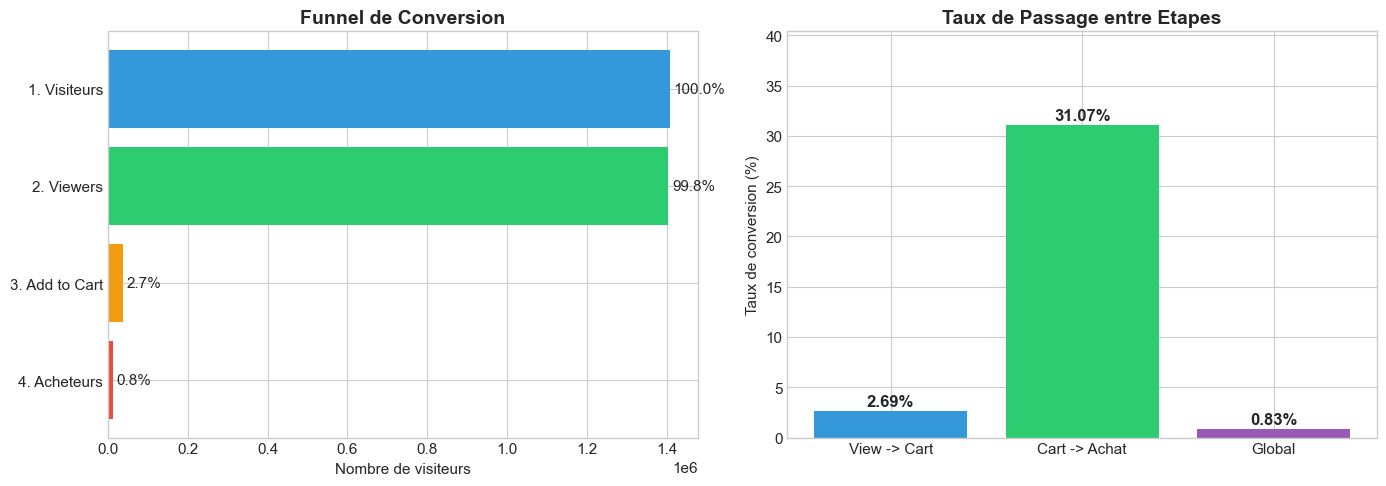


[ANALYSE]
  - Perte View -> Cart : 1,366,457 visiteurs (97.3%)
  - Perte Cart -> Achat : 26,003 visiteurs (68.9%)


In [3]:
# =============================================================================
# FUNNEL DE CONVERSION
# =============================================================================

# Construction du funnel
funnel_data = {
    'Etape': ['1. Visiteurs', '2. Viewers', '3. Add to Cart', '4. Acheteurs'],
    'Visiteurs': [total_visitors, visitors_view, visitors_cart, visitors_purchase],
}

funnel_df = pd.DataFrame(funnel_data)
funnel_df['Pourcentage'] = (funnel_df['Visiteurs'] / total_visitors * 100).round(2)
funnel_df['Taux_etape'] = (funnel_df['Visiteurs'] / funnel_df['Visiteurs'].shift(1) * 100).round(2)
funnel_df['Perte'] = funnel_df['Visiteurs'].shift(1) - funnel_df['Visiteurs']

print("FUNNEL DE CONVERSION")
print("=" * 70)
print(funnel_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Funnel en barres
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].barh(funnel_df['Etape'][::-1], funnel_df['Visiteurs'][::-1], color=colors[::-1])
axes[0].set_xlabel('Nombre de visiteurs')
axes[0].set_title('Funnel de Conversion', fontsize=14, fontweight='bold')

# Annotations
for bar, pct in zip(bars, funnel_df['Pourcentage'][::-1]):
    axes[0].text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', va='center', fontsize=11)

# Graphique 2 : Taux de passage entre etapes
taux_passage = [
    ('View -> Cart', view_to_cart_rate),
    ('Cart -> Achat', cart_to_purchase_rate),
    ('Global', overall_conversion_rate)
]
labels, values = zip(*taux_passage)
bars2 = axes[1].bar(labels, values, color=['#3498db', '#2ecc71', '#9b59b6'])
axes[1].set_ylabel('Taux de conversion (%)')
axes[1].set_title('Taux de Passage entre Etapes', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max(values) * 1.3)

for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/funnel_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[ANALYSE]")
print(f"  - Perte View -> Cart : {visitors_view - visitors_cart:,} visiteurs ({100-view_to_cart_rate:.1f}%)")
print(f"  - Perte Cart -> Achat : {visitors_cart - visitors_purchase:,} visiteurs ({cart_abandonment_rate:.1f}%)")

### Interpretation Funnel

**Diagnostic du tunnel :**

| Etape | Taux | Benchmark | Statut |
|-------|------|-----------|--------|
| View -> Cart | ~2.6% | 5-10% | Sous-performance |
| Cart -> Achat | ~32% | 30-40% | Dans la norme |

**Conclusion :**
Le probleme principal n'est PAS l'abandon de panier (taux normal) mais le faible taux d'ajout au panier.

**Hypotheses a investiguer :**
- Fiches produits peu convaincantes
- Prix non competitifs
- Mauvaise UX du bouton "Ajouter au panier"
- Produits mal cibles vs audience

---
## 3. Segmentation des Visiteurs

SEGMENTATION DES VISITEURS
  browser              :  1,368,715 ( 97.2%)
  cart_abandoner       :     27,146 (  1.9%)
  buyer                :     11,719 (  0.8%)

COMPORTEMENT MOYEN PAR SEGMENT
--------------------------------------------------
                total_events  unique_items  n_view  n_addtocart  n_transaction
segment                                                                       
browser                 1.71          1.41    1.71         0.00           0.00
buyer                  19.68          9.54   15.42         2.34           1.92
cart_abandoner          7.02          3.71    5.49         1.53           0.00


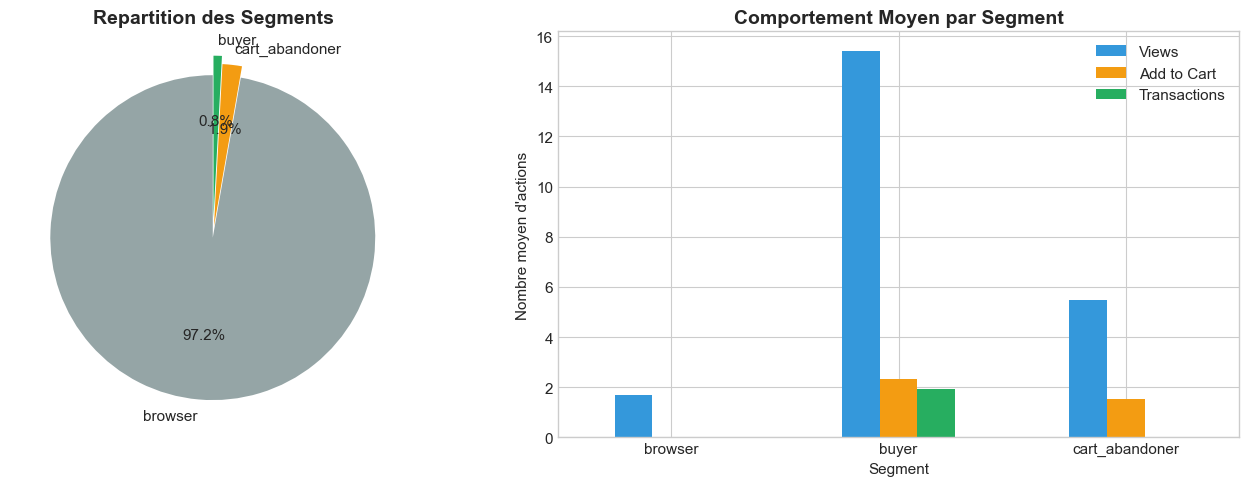

In [4]:
# =============================================================================
# ANALYSE DES SEGMENTS VISITEURS
# =============================================================================

# Distribution des segments
segment_counts = visitors['segment'].value_counts()
segment_pct = (segment_counts / len(visitors) * 100).round(2)

print("SEGMENTATION DES VISITEURS")
print("=" * 50)
for seg, count in segment_counts.items():
    pct = segment_pct[seg]
    print(f"  {seg:<20} : {count:>10,} ({pct:>5.1f}%)")

# Comportement moyen par segment
segment_behavior = visitors.groupby('segment').agg({
    'total_events': 'mean',
    'unique_items': 'mean',
    'n_view': 'mean',
    'n_addtocart': 'mean',
    'n_transaction': 'mean'
}).round(2)

print("\nCOMPORTEMENT MOYEN PAR SEGMENT")
print("-" * 50)
print(segment_behavior.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart segments
colors_seg = {'browser': '#95a5a6', 'cart_abandoner': '#f39c12', 'buyer': '#27ae60'}
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
            colors=[colors_seg[s] for s in segment_counts.index],
            explode=[0.02, 0.05, 0.1], startangle=90)
axes[0].set_title('Repartition des Segments', fontsize=14, fontweight='bold')

# Barplot comportement
segment_behavior[['n_view', 'n_addtocart', 'n_transaction']].plot(
    kind='bar', ax=axes[1], color=['#3498db', '#f39c12', '#27ae60'])
axes[1].set_title('Comportement Moyen par Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Nombre moyen d\'actions')
axes[1].legend(['Views', 'Add to Cart', 'Transactions'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/segmentation_visiteurs.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# =============================================================================
# VALEUR DES SEGMENTS
# =============================================================================

# Calcul de la valeur potentielle
print("POTENTIEL BUSINESS PAR SEGMENT")
print("=" * 60)

# Cart abandoners : potentiel de recuperation
cart_abandoners = segment_counts.get('cart_abandoner', 0)
potential_recovery = cart_abandoners * cart_to_purchase_rate / 100

print(f"\n[CART ABANDONERS - {cart_abandoners:,} visiteurs]")
print(f"  Ces visiteurs ont montre une intention d'achat")
print(f"  Potentiel si on atteint le taux cart->achat normal : +{int(potential_recovery):,} acheteurs")
print(f"  Action : Emails de relance, remarketing, offres personnalisees")

# Browsers : potentiel d'engagement
browsers = segment_counts.get('browser', 0)
if_engaged = browsers * (view_to_cart_rate / 100) * (cart_to_purchase_rate / 100)

print(f"\n[BROWSERS - {browsers:,} visiteurs]")
print(f"  Visiteurs qui regardent mais n'ajoutent pas au panier")
print(f"  Si on double le taux view->cart : +{int(if_engaged * 2):,} acheteurs potentiels")
print(f"  Action : Ameliorer les fiches produits, recommandations, pop-ups")

# Buyers : fidelisation
buyers_count = segment_counts.get('buyer', 0)
avg_transactions = visitors[visitors['segment'] == 'buyer']['n_transaction'].mean()

print(f"\n[BUYERS - {buyers_count:,} visiteurs]")
print(f"  Clients existants - moyenne {avg_transactions:.1f} transactions/client")
print(f"  Potentiel : Augmenter la frequence d'achat et le panier moyen")
print(f"  Action : Programme fidelite, cross-sell, newsletters personnalisees")

POTENTIEL BUSINESS PAR SEGMENT

[CART ABANDONERS - 27,146 visiteurs]
  Ces visiteurs ont montre une intention d'achat
  Potentiel si on atteint le taux cart->achat normal : +8,433 acheteurs
  Action : Emails de relance, remarketing, offres personnalisees

[BROWSERS - 1,368,715 visiteurs]
  Visiteurs qui regardent mais n'ajoutent pas au panier
  Si on double le taux view->cart : +22,846 acheteurs potentiels
  Action : Ameliorer les fiches produits, recommandations, pop-ups

[BUYERS - 11,719 visiteurs]
  Clients existants - moyenne 1.9 transactions/client
  Potentiel : Augmenter la frequence d'achat et le panier moyen
  Action : Programme fidelite, cross-sell, newsletters personnalisees


---
## 4. Analyse Temporelle

In [6]:
# =============================================================================
# PATTERNS TEMPORELS
# =============================================================================

# Activite par jour de la semaine
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
events['day_name'] = pd.Categorical(events['datetime'].dt.day_name(), categories=days_order, ordered=True)

daily_stats = events.groupby('day_name').agg({
    'visitorid': 'count',
    'event': lambda x: (x == 'transaction').sum()
}).rename(columns={'visitorid': 'events', 'event': 'transactions'})

daily_stats['conversion'] = (daily_stats['transactions'] / daily_stats['events'] * 100).round(3)

print("PERFORMANCE PAR JOUR DE LA SEMAINE")
print("=" * 60)
print(daily_stats.to_string())

# Meilleur/pire jour
best_day = daily_stats['transactions'].idxmax()
worst_day = daily_stats['transactions'].idxmin()
print(f"\n  Meilleur jour : {best_day} ({daily_stats.loc[best_day, 'transactions']:,} transactions)")
print(f"  Pire jour     : {worst_day} ({daily_stats.loc[worst_day, 'transactions']:,} transactions)")

PERFORMANCE PAR JOUR DE LA SEMAINE
           events  transactions  conversion
day_name                                   
Monday     439738          3848       0.875
Tuesday    447006          3973       0.889
Wednesday  431059          4151       0.963
Thursday   418672          3750       0.896
Friday     379624          2929       0.772
Saturday   305167          1811       0.593
Sunday     334375          1995       0.597

  Meilleur jour : Wednesday (4,151 transactions)
  Pire jour     : Saturday (1,811 transactions)


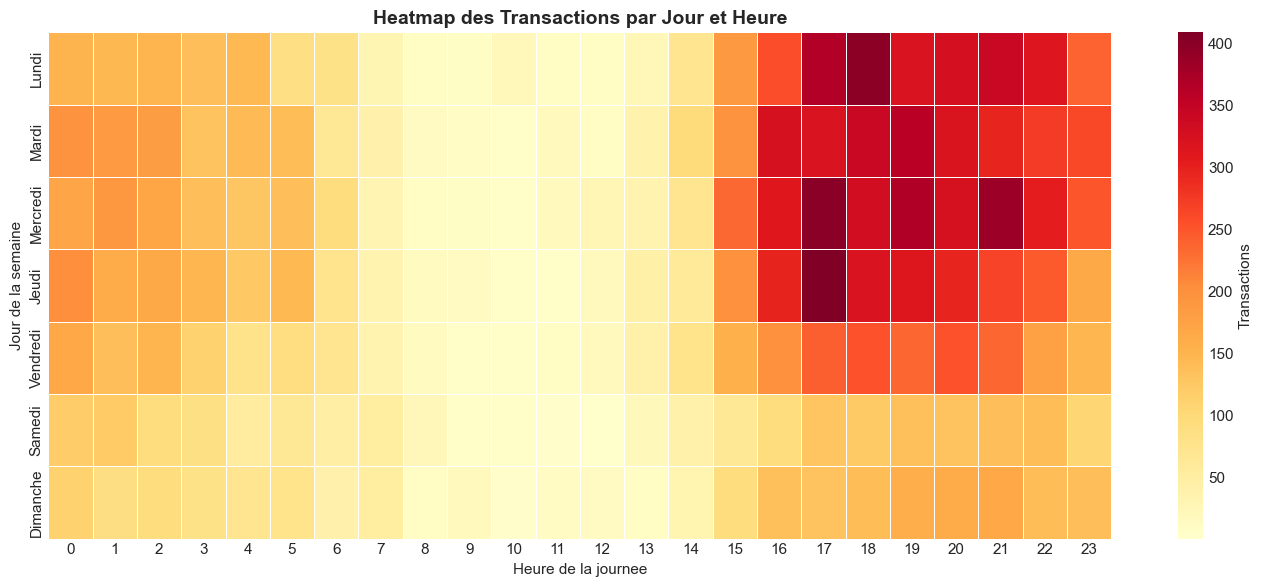


[INSIGHT] Pic de transactions : 17h
  Recommandation : Concentrer les campagnes marketing avant ce creneau


In [7]:
# =============================================================================
# HEATMAP HORAIRE
# =============================================================================

# Transactions par heure et jour
events['hour'] = events['datetime'].dt.hour
events['dow'] = events['datetime'].dt.dayofweek

heatmap_data = events[events['event'] == 'transaction'].pivot_table(
    index='dow',
    columns='hour',
    aggfunc='size',
    fill_value=0
)

# Renommer les index
day_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
heatmap_data.index = day_labels

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, fmt='d', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Transactions'})
ax.set_title('Heatmap des Transactions par Jour et Heure', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure de la journee')
ax.set_ylabel('Jour de la semaine')

plt.tight_layout()
plt.savefig('../outputs/figures/heatmap_transactions.png', dpi=150, bbox_inches='tight')
plt.show()

# Pic d'activite
peak_hour = events[events['event'] == 'transaction']['hour'].mode()[0]
print(f"\n[INSIGHT] Pic de transactions : {peak_hour}h")
print(f"  Recommandation : Concentrer les campagnes marketing avant ce creneau")

---
## 5. Analyse Produits

In [8]:
# =============================================================================
# TOP PRODUITS
# =============================================================================

# Top 10 par ventes
top_sellers = products.nlargest(10, 'n_transaction')[[
    'itemid', 'n_view', 'n_addtocart', 'n_transaction', 'view_to_cart', 'cart_to_purchase'
]]

print("TOP 10 PRODUITS PAR VENTES")
print("=" * 80)
print(top_sellers.to_string(index=False))

# Top 10 par taux de conversion (avec minimum de vues)
min_views = 100  # Filtre pour avoir des resultats significatifs
high_converters = products[products['n_view'] >= min_views].nlargest(10, 'view_to_cart')[[
    'itemid', 'n_view', 'n_addtocart', 'n_transaction', 'view_to_cart'
]]

print(f"\nTOP 10 PRODUITS PAR TAUX DE CONVERSION (min {min_views} vues)")
print("=" * 80)
print(high_converters.to_string(index=False))

TOP 10 PRODUITS PAR VENTES
 itemid  n_view  n_addtocart  n_transaction  view_to_cart  cart_to_purchase
 461686    2538          304            133      0.119779          0.437500
 119736     752           44             97      0.058511          2.204545
 213834     293           17             92      0.058020          5.411765
   7943    1346           97             46      0.072065          0.474227
 312728     947          161             46      0.170011          0.285714
 445351     939           89             45      0.094782          0.505618
  48030     986           95             41      0.096349          0.431579
 248455     575           52             38      0.090435          0.730769
 420960     795           60             38      0.075472          0.633333
  17478     631           72             37      0.114105          0.513889

TOP 10 PRODUITS PAR TAUX DE CONVERSION (min 100 vues)
 itemid  n_view  n_addtocart  n_transaction  view_to_cart
 140527     111         

ANALYSE DU CATALOGUE
  Produits avec ventes    : 12,025 (5.1%)
  Produits sans ventes    : 223,036 (94.9%)

[PARETO]
  62.6% des produits generent 80% des ventes
  Soit 7,533 produits sur 12,025


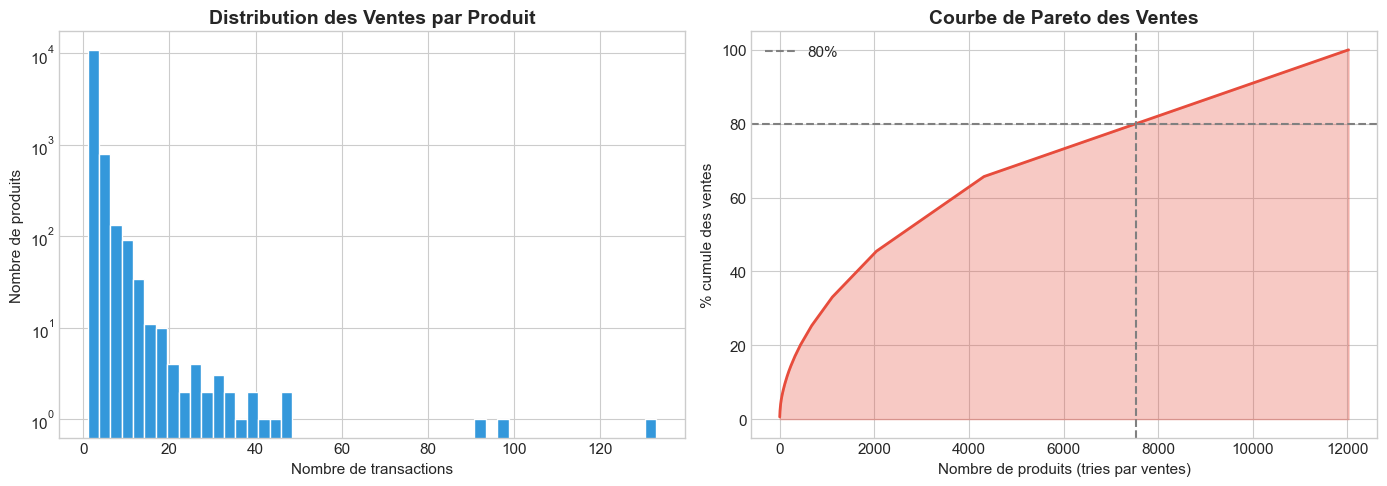

In [9]:
# =============================================================================
# ANALYSE DE LA LONGUE TRAINE
# =============================================================================

# Distribution des ventes
products_with_sales = products[products['n_transaction'] > 0]
products_no_sales = products[products['n_transaction'] == 0]

print("ANALYSE DU CATALOGUE")
print("=" * 60)
print(f"  Produits avec ventes    : {len(products_with_sales):,} ({len(products_with_sales)/len(products)*100:.1f}%)")
print(f"  Produits sans ventes    : {len(products_no_sales):,} ({len(products_no_sales)/len(products)*100:.1f}%)")

# Loi de Pareto (80/20)
products_sorted = products_with_sales.sort_values('n_transaction', ascending=False)
products_sorted['cumsum'] = products_sorted['n_transaction'].cumsum()
products_sorted['cumsum_pct'] = products_sorted['cumsum'] / products_sorted['n_transaction'].sum() * 100

# Trouver le point 80%
n_products_80 = (products_sorted['cumsum_pct'] <= 80).sum()
pct_products_80 = n_products_80 / len(products_with_sales) * 100

print(f"\n[PARETO]")
print(f"  {pct_products_80:.1f}% des produits generent 80% des ventes")
print(f"  Soit {n_products_80:,} produits sur {len(products_with_sales):,}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des ventes
axes[0].hist(products_with_sales['n_transaction'], bins=50, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Nombre de transactions')
axes[0].set_ylabel('Nombre de produits')
axes[0].set_title('Distribution des Ventes par Produit', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')

# Courbe de Pareto
x_pareto = range(1, len(products_sorted) + 1)
axes[1].plot(x_pareto, products_sorted['cumsum_pct'], color='#e74c3c', linewidth=2)
axes[1].axhline(y=80, color='gray', linestyle='--', label='80%')
axes[1].axvline(x=n_products_80, color='gray', linestyle='--')
axes[1].fill_between(x_pareto, products_sorted['cumsum_pct'], alpha=0.3, color='#e74c3c')
axes[1].set_xlabel('Nombre de produits (tries par ventes)')
axes[1].set_ylabel('% cumule des ventes')
axes[1].set_title('Courbe de Pareto des Ventes', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/analyse_produits.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Recommandations Business

In [10]:
# =============================================================================
# SYNTHESE ET RECOMMANDATIONS
# =============================================================================

print("=" * 70)
print("SYNTHESE EXECUTIVE")
print("=" * 70)

print("""
SITUATION ACTUELLE
------------------
Le site e-commerce genere un trafic significatif (1.4M visiteurs) mais 
le taux de conversion est faible (<1%). L'analyse revele que le principal
point de friction est le passage de la consultation a l'ajout au panier,
et non l'abandon de panier qui reste dans les normes du secteur.
""")

print("\nKPIs CLES")
print("-" * 40)
print(f"  Conversion globale     : {overall_conversion_rate:.2f}%")
print(f"  Taux View->Cart        : {view_to_cart_rate:.2f}%")
print(f"  Taux abandon panier    : {cart_abandonment_rate:.1f}%")
print(f"  Produits actifs        : {len(products_with_sales)/len(products)*100:.1f}%")

print("""
AXES D'AMELIORATION PRIORITAIRES
--------------------------------

1. OPTIMISER LE TAUX VIEW->CART (Impact: ELEVE)
   - Ameliorer les fiches produits (photos, descriptions, avis)
   - Tester differents CTAs "Ajouter au panier"
   - Afficher les stocks/urgence ("Plus que 3 en stock")
   - Mettre en avant les promotions
   Objectif : Passer de 2.6% a 5% (+92% de croissance potentielle)

2. RECUPERER LES ABANDONS PANIER (Impact: MOYEN)
   - Emails de relance automatiques (H+1, H+24, J+3)
   - Remarketing Facebook/Google
   - Offrir la livraison gratuite au-dessus d'un seuil
   Objectif : Recuperer 10% des abandons = +2,700 acheteurs

3. ACTIVER LES BROWSERS (Impact: MOYEN-LONG TERME)
   - Personnalisation du contenu
   - Pop-up de capture email avant sortie
   - Recommandations produits basees sur le comportement
   Cible : 1.37M visiteurs a engager

4. FIDELISER LES ACHETEURS (Impact: ELEVE SUR LTV)
   - Programme de fidelite
   - Cross-sell post-achat
   - Newsletter personnalisee
   Base : 11,700 clients existants a developper

5. OPTIMISER LE CATALOGUE (Impact: MOYEN)
   - Supprimer/archiver les produits sans vues
   - Mettre en avant les best-sellers
   - Analyser pourquoi 89% des produits ne vendent pas
""")

print("\nPROCHAINES ETAPES")
print("-" * 40)
print("  1. A/B test sur les fiches produits (2 semaines)")
print("  2. Mise en place emails abandon panier (1 semaine)")
print("  3. Audit UX du tunnel de conversion")
print("  4. Analyse qualitative des browsers (sondage)")

print("\n" + "=" * 70)

SYNTHESE EXECUTIVE

SITUATION ACTUELLE
------------------
Le site e-commerce genere un trafic significatif (1.4M visiteurs) mais 
le taux de conversion est faible (<1%). L'analyse revele que le principal
point de friction est le passage de la consultation a l'ajout au panier,
et non l'abandon de panier qui reste dans les normes du secteur.


KPIs CLES
----------------------------------------
  Conversion globale     : 0.83%
  Taux View->Cart        : 2.69%
  Taux abandon panier    : 68.9%
  Produits actifs        : 5.1%

AXES D'AMELIORATION PRIORITAIRES
--------------------------------

1. OPTIMISER LE TAUX VIEW->CART (Impact: ELEVE)
   - Ameliorer les fiches produits (photos, descriptions, avis)
   - Tester differents CTAs "Ajouter au panier"
   - Afficher les stocks/urgence ("Plus que 3 en stock")
   - Mettre en avant les promotions
   Objectif : Passer de 2.6% a 5% (+92% de croissance potentielle)

2. RECUPERER LES ABANDONS PANIER (Impact: MOYEN)
   - Emails de relance automatiques 

In [11]:
# =============================================================================
# EXPORT DU RAPPORT KPI
# =============================================================================

# Creation du rapport de synthese
kpi_summary = {
    'Metrique': [
        'Visiteurs uniques',
        'Interactions totales',
        'Produits catalogue',
        'Transactions',
        'Taux conversion global',
        'Taux View->Cart',
        'Taux Cart->Achat',
        'Taux abandon panier',
        'Produits avec ventes',
        'Periode analyse (jours)'
    ],
    'Valeur': [
        total_visitors,
        len(events),
        total_products,
        n_transactions,
        f"{overall_conversion_rate:.2f}%",
        f"{view_to_cart_rate:.2f}%",
        f"{cart_to_purchase_rate:.2f}%",
        f"{cart_abandonment_rate:.1f}%",
        f"{len(products_with_sales)/len(products)*100:.1f}%",
        (events['datetime'].max() - events['datetime'].min()).days
    ]
}

kpi_df = pd.DataFrame(kpi_summary)
kpi_df.to_csv('../outputs/data/kpi_business_summary.csv', index=False)

print("RAPPORT KPI EXPORTE")
print("=" * 50)
print(kpi_df.to_string(index=False))
print(f"\nFichier : outputs/data/kpi_business_summary.csv")

RAPPORT KPI EXPORTE
               Metrique  Valeur
      Visiteurs uniques 1407580
   Interactions totales 2755641
     Produits catalogue  235061
           Transactions   22457
 Taux conversion global   0.83%
        Taux View->Cart   2.69%
       Taux Cart->Achat  31.07%
    Taux abandon panier   68.9%
   Produits avec ventes    5.1%
Periode analyse (jours)     137

Fichier : outputs/data/kpi_business_summary.csv
